# Dropout Prevention - Report
This notebook is the final reporting notebook for the dropout prevention module. It tests the trained **XGBoost** model on held-out test data, summarizes the results, and shows example student inputs similar to what will appear in the Streamlit dashboard.


In [1]:
from pathlib import Path
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

## Load the Processed Data and Saved Model
The model and feature list are loaded from the training step. The same 80/20 stratified split is recreated so the model can be tested on unseen data.


In [2]:
base_dir = Path.cwd().resolve()
if not (base_dir / "data").exists():
    base_dir = base_dir.parent.parent

df = pd.read_csv(base_dir / "data" / "processed" / "dropout" / "dropout_preprocessed.csv")
model = joblib.load(base_dir / "models" / "dropout" / "oula_ews_model.pkl")
features = joblib.load(base_dir / "models" / "dropout" / "model_features.pkl")

X = df[features]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Processed dataset shape:', df.shape)
print('Test set shape:', X_test.shape)
print('Features used by the model:')
print(features)

Processed dataset shape: (32593, 19)
Test set shape: (6519, 7)
Features used by the model:
['total_clicks', 'active_days', 'relative_engagement', 'avg_score', 'avg_lateness', 'num_of_prev_attempts', 'studied_credits']


## Test the XGBoost Model on Held-Out Test Data

In [3]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print('Classification Report:')
print(classification_report(y_test, y_pred))
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}')

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.43      0.56      3077
           1       0.64      0.92      0.76      3442

    accuracy                           0.69      6519
   macro avg       0.73      0.67      0.66      6519
weighted avg       0.73      0.69      0.66      6519

ROC-AUC Score: 0.8416


## Sample Test Predictions
The table below shows a few records from the held-out test set with the predicted risk probability and predicted class. This is useful for reporting and discussion.


In [4]:
sample_test_predictions = X_test.copy().reset_index(drop=True)
sample_test_predictions['actual_target'] = y_test.reset_index(drop=True)
sample_test_predictions['predicted_target'] = y_pred
sample_test_predictions['risk_probability'] = y_prob

sample_test_predictions.head(10)

,total_clicks,active_days,relative_engagement,avg_score,avg_lateness,num_of_prev_attempts,studied_credits,actual_target,predicted_target,risk_probability
0,713.0,19.0,-0.178868,84.000000,0.0,0,60,0,1,0.670191
1,39.0,7.0,-0.445200,0.000000,0.0,0,30,1,1,0.621293
2,61.0,10.0,-1.097677,70.000000,0.0,1,90,0,1,0.701046
3,150.0,10.0,0.440893,0.000000,0.0,0,30,0,1,0.525417
4,1009.0,29.0,0.445339,80.666667,0.0,0,120,0,1,0.613584
5,1410.0,37.0,2.594464,70.000000,-6.0,0,60,0,0,0.373144
6,405.0,19.0,-0.442010,76.000000,-1.0,0,90,1,1,0.662900
7,5.0,1.0,-0.826208,0.000000,0.0,1,480,1,1,0.996485
8,5.0,2.0,-0.709926,0.000000,0.0,0,30,1,1,0.690779
9,1080.0,39.0,0.460014,64.000000,-2.0,0,120,0,1,0.662028


## Dashboard-Style Example Inputs
The examples below simulate what a user might enter in the dashboard for individual student risk prediction.


In [5]:
dashboard_examples = pd.DataFrame([
    {
        'student': 'Example 1 - low risk',
        'total_clicks': 220,
        'active_days': 18,
        'relative_engagement': 0.45,
        'avg_score': 78.0,
        'avg_lateness': 0.0,
        'num_of_prev_attempts': 0,
        'studied_credits': 60,
    },
    {
        'student': 'Example 2 - medium risk',
        'total_clicks': 95,
        'active_days': 9,
        'relative_engagement': -0.35,
        'avg_score': 55.0,
        'avg_lateness': 2.0,
        'num_of_prev_attempts': 1,
        'studied_credits': 60,
    },
    {
        'student': 'Example 3 - high risk',
        'total_clicks': 25,
        'active_days': 4,
        'relative_engagement': -1.20,
        'avg_score': 32.0,
        'avg_lateness': 7.0,
        'num_of_prev_attempts': 2,
        'studied_credits': 90,
    },
    {
        'student': 'Example 4 - safe',
        'total_clicks': 380,
        'active_days': 25,
        'relative_engagement': 1.10,
        'avg_score': 88.0,
        'avg_lateness': 0.0,
        'num_of_prev_attempts': 0,
        'studied_credits': 60,
    },
])

dashboard_examples

,student,total_clicks,active_days,relative_engagement,avg_score,avg_lateness,num_of_prev_attempts,studied_credits
0,Example 1 - low risk,220,18,0.45,78.0,0.0,0,60
1,Example 2 - medium risk,95,9,-0.35,55.0,2.0,1,60
2,Example 3 - high risk,25,4,-1.20,32.0,7.0,2,90
3,Example 4 - safe,380,25,1.10,88.0,0.0,0,60


## Predict Risk for the Dashboard Examples
This output is very close to what the Streamlit app will show: a probability score and a simple risk label.


In [6]:
example_inputs = dashboard_examples[features].copy()
dashboard_examples['risk_probability'] = model.predict_proba(example_inputs)[:, 1]
dashboard_examples['predicted_label'] = dashboard_examples['risk_probability'].apply(
    lambda x: 'At Risk' if x >= 0.5 else 'Safe'
)

dashboard_examples[['student'] + ['risk_probability', 'predicted_label']]

,student,risk_probability,predicted_label
0,Example 1 - low risk,0.549497,At Risk
1,Example 2 - medium risk,0.844765,At Risk
2,Example 3 - high risk,0.995100,At Risk
3,Example 4 - safe,0.392316,Safe


## Explain Why the Dashboard Examples Were Flagged
This section uses **SHAP** to explain the dashboard examples. A positive SHAP value pushes the prediction toward **At Risk**, while a negative SHAP value pushes it toward **Safe**. The summary table below highlights the strongest reasons behind each example prediction.


In [7]:
import shap

explainer = shap.TreeExplainer(model)
example_shap = explainer(example_inputs)

shap_values_df = pd.DataFrame(example_shap.values, columns=features)


def top_reasons(row_values, row_inputs, top_n=3):
    order = row_values.abs().sort_values(ascending=False).index[:top_n]
    reasons = []
    for feat in order:
        direction = 'increased risk' if row_values[feat] > 0 else 'reduced risk'
        reasons.append(f"{feat}={row_inputs[feat]} ({direction})")
    return '; '.join(reasons)


dashboard_explanations = dashboard_examples[['student', 'risk_probability', 'predicted_label']].copy()
dashboard_explanations['top_reasons'] = [
    top_reasons(shap_values_df.iloc[i], example_inputs.iloc[i])
    for i in range(len(dashboard_examples))
]

dashboard_explanations


,student,risk_probability,predicted_label,top_reasons
0,Example 1 - low risk,0.549497,At Risk,relative_engagement=0.45 (reduced risk); avg_s...
1,Example 2 - medium risk,0.844765,At Risk,avg_score=55.0 (increased risk); total_clicks=...
2,Example 3 - high risk,0.995100,At Risk,relative_engagement=-1.2 (increased risk); avg...
3,Example 4 - safe,0.392316,Safe,relative_engagement=1.1 (reduced risk); avg_sc...


## SHAP Waterfall Plots for Dashboard Examples
These plots show how each feature pushes the final prediction up or down for each example student.


Example 1 - low risk


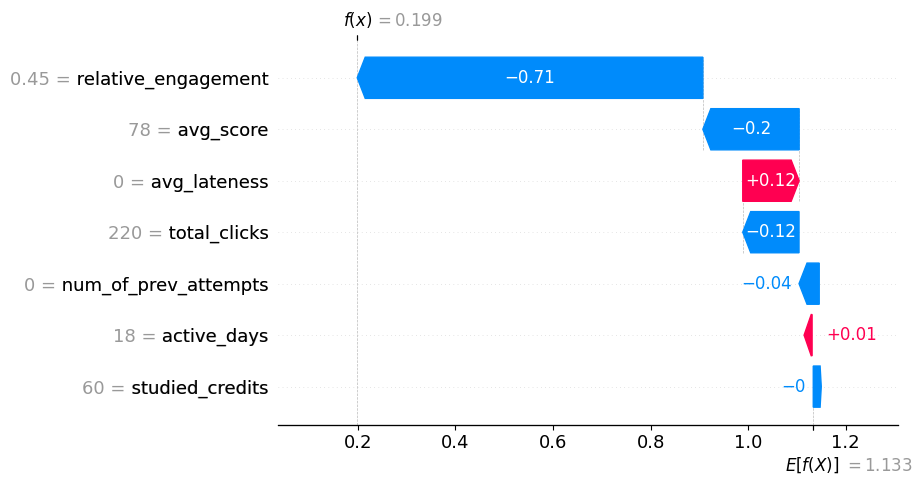

Example 2 - medium risk


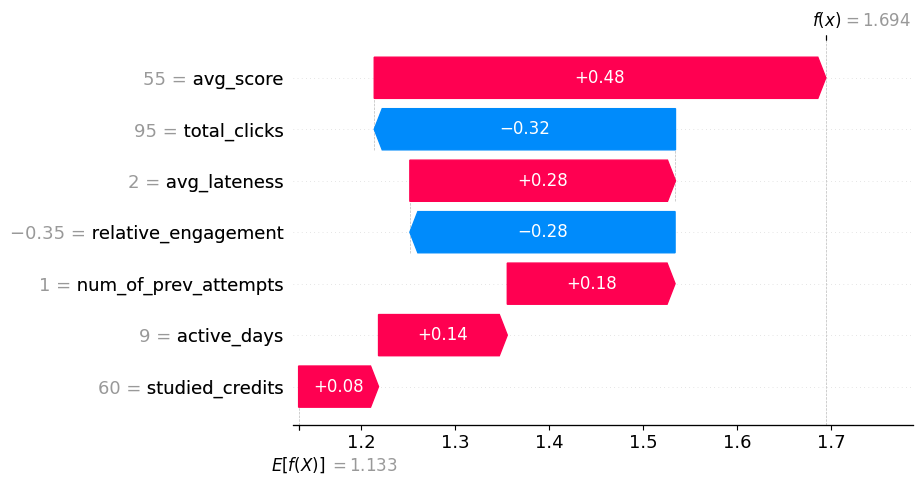

Example 3 - high risk


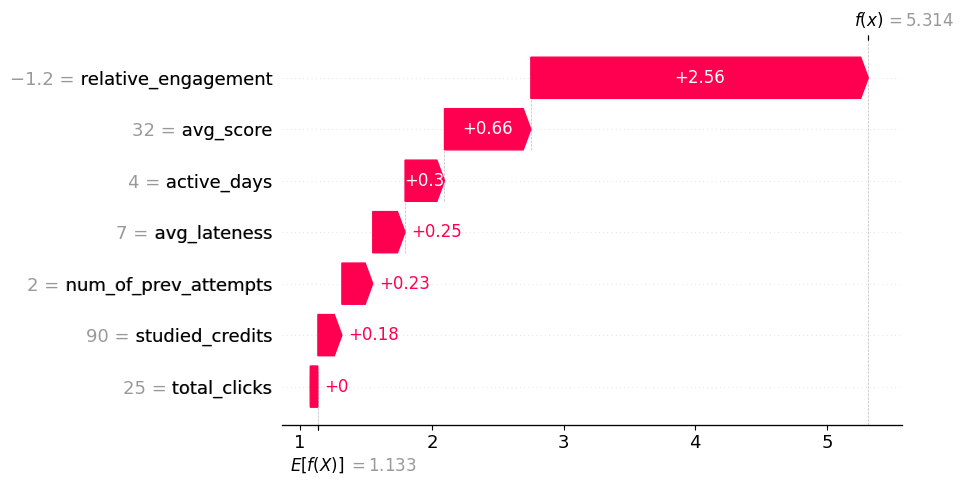

Example 4 - safe


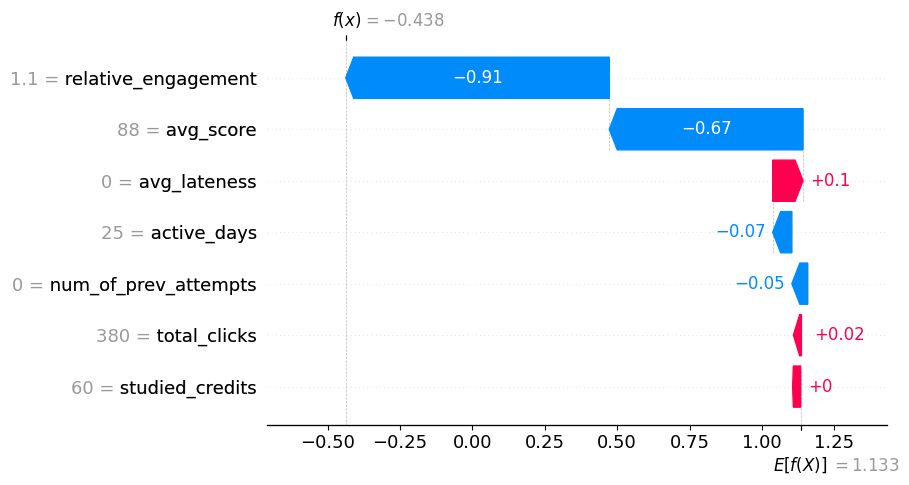

In [8]:
for i, student_case in enumerate(dashboard_examples['student']):
    print(student_case)
    shap.plots.waterfall(example_shap[i], max_display=7)

## Risk Distribution for the Dashboard Examples
This small chart is useful for demonstration because it shows how the example students are distributed by predicted status.


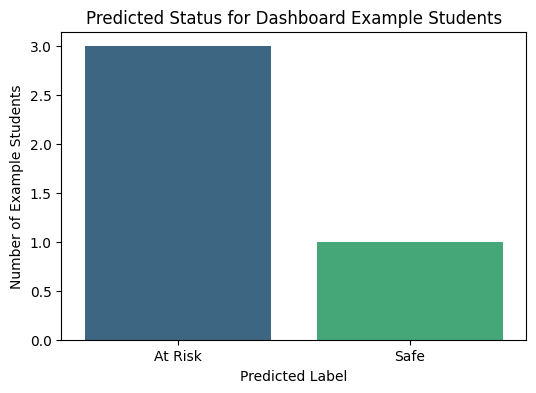

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(
    data=dashboard_examples,
    x='predicted_label',
    hue='predicted_label',
    palette='viridis',
    legend=False
)
plt.title('Predicted Status for Dashboard Example Students')
plt.xlabel('Predicted Label')
plt.ylabel('Number of Example Students')
plt.show()